# Offline Deep Reinforcement Learning for Sepsis Treatment Recommendation
## Baseline Models


| Baseline | Input | Level |
|---|---|---|
| Logistic Regression | Extended state features (STATE_EXT) | Timestep |
| Random Forest | Extended state features (STATE_EXT) | Timestep |
| MLP (tabular) | Extended state features (STATE_EXT) | Timestep |
| ResNet-18 (frozen) | Patient heatmap 224×224 (base STATE_COLS) | Patient |
| Behaviour Cloning MDP | MDP states from .npz (STATE_EXT) | Timestep |


---
## 0. Imports & Output Directories

In [ ]:
import sys
import os
import json
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix

from tabular_baselines import run_tabular_baselines
from imaging_baseline import (
    prepare_imaging_splits,
    build_data_loaders,
    build_resnet18,
    train_resnet18,
    evaluate_resnet18,
)
from behaviour_cloning import (
    load_mdp_transitions,
    split_and_scale_mdp,
    train_and_evaluate_bc,
)
from results_utils import build_results_table, print_results_table, save_results_csv
from data_preprocessing import (
    STATE_COLS, ID_COL, TIME_COL, FLUID_COL, VASO_COL, SURVIVAL_COL,
)

FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures', 'baselines')
DATA_DIR    = os.path.join(PROJECT_ROOT, 'data', 'results')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR,    exist_ok=True)

def fig_path(fname):  return os.path.join(FIGURES_DIR, fname)
def data_path(fname): return os.path.join(DATA_DIR,    fname)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE = {
    'blue'  : '#2C7BB6', 'red'    : '#D7191C',
    'green' : '#1A9641', 'purple' : '#7B2D8B',
    'orange': '#FF7F00', 'gold'   : '#D4A017',
}
C1, C2, C3 = PALETTE['blue'], PALETTE['red'], PALETTE['green']

plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.figsize'   : (12, 5),
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})
sns.set_theme(style='whitegrid')

print(f'Figures  → {FIGURES_DIR}')
print(f'CSV data → {DATA_DIR}')
print('All imports successful.')

Figures  → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines
CSV data → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\data\results
All imports successful.


---
## 1. Data Loading

`sepsis_preprocessed.csv` is the fully processed DataFrame saved by W2 Section 12.  
It contains the base state columns **plus** all engineered features (SOFA, SIRS, Δ-features,
severity flags) **plus** metadata columns (IDs, actions, rewards).  
We load `state_ext_cols.json` — also saved by W2 — to get the **exact feature list** used
during preprocessing, which guarantees no action or metadata column leaks into X.

In [ ]:
CSV_PATH      = os.path.join(PROJECT_ROOT, 'data', 'sepsis_preprocessed.csv')
STATE_EXT_PATH = os.path.join(PROJECT_ROOT, 'data', 'preprocessed', 'state_ext_cols.json')

df_clean = pd.read_csv(CSV_PATH)

with open(STATE_EXT_PATH) as f:
    STATE_EXT = json.load(f)

print(f'Shape                : {df_clean.shape}')
print(f'Unique patients      : {df_clean[ID_COL].nunique():,}')
print(f'STATE_EXT features   : {len(STATE_EXT)}')
print(f'First 8 features     : {STATE_EXT[:8]}')

# Sanity check: none of the feature columns should be the target
assert 'action_combined' not in STATE_EXT, 'action_combined must not be in STATE_EXT'
assert 'action' not in STATE_EXT,          'action must not be in STATE_EXT'
for col in STATE_EXT:
    assert col in df_clean.columns, f'Column {col} from STATE_EXT not found in CSV'

X = df_clean[STATE_EXT].values
y = df_clean['action_combined'].values

print(f'\nX shape              : {X.shape}')
print(f'y unique actions     : {np.unique(y).size} / 25')
print(f'y range              : {y.min()} – {y.max()}')

Shape                : (43280, 75)
Unique patients      : 2,164
STATE_EXT features   : 56
First 8 features     : ['HR', 'SysBP', 'MeanBP', 'DiaBP', 'RR', 'Temp', 'SpO2', 'GCS']

X shape              : (43280, 56)
y unique actions     : 25 / 25
y range              : 0 – 24


### 1.1 Action Distribution

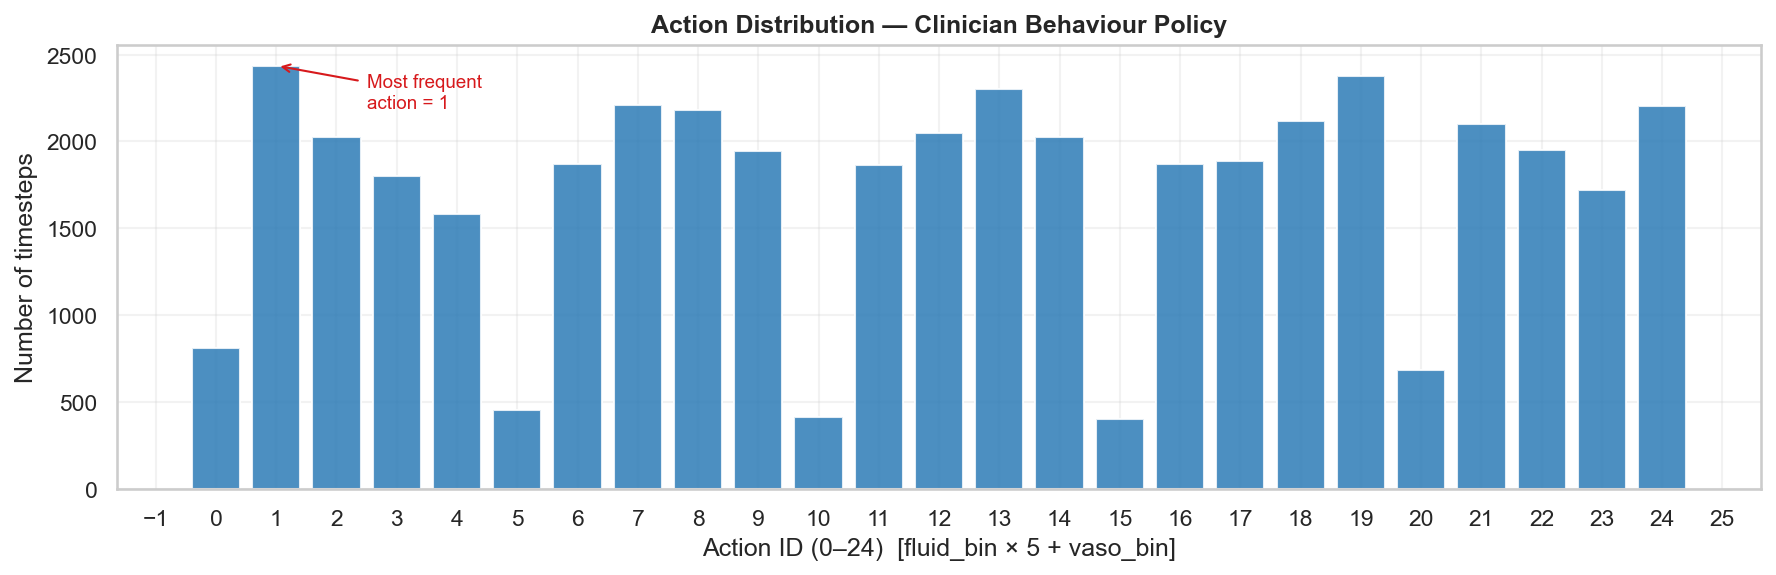

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\action_distribution.png


In [ ]:
action_counts = pd.Series(y).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(action_counts.index, action_counts.values, color=C1, edgecolor='white', alpha=0.85)
ax.set_xlabel('Action ID (0–24)  [fluid_bin × 5 + vaso_bin]')
ax.set_ylabel('Number of timesteps')
ax.set_title('Action Distribution — Clinician Behaviour Policy', fontweight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
top_a = action_counts.idxmax()
ax.annotate(
    f'Most frequent\naction = {top_a}',
    xy=(top_a, action_counts[top_a]),
    xytext=(top_a + 1.5, action_counts[top_a] * 0.9),
    arrowprops=dict(arrowstyle='->', color=C2),
    color=C2, fontsize=9,
)
plt.tight_layout()
plt.savefig(fig_path('action_distribution.png'), bbox_inches='tight')
plt.show()
print(f"Saved → {fig_path('action_distribution.png')}")

---
## 2. Train / Validation / Test Split  (64 % / 16 % / 20 %)

Stratified by action label.  MinMax scaling is fitted **only on the training fold**.

In [ ]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, random_state=RANDOM_STATE, stratify=y_tv
)

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.1f} %)')
print(f'Val   : {X_val.shape}   ({len(X_val)/len(X)*100:.1f} %)')
print(f'Test  : {X_test.shape}   ({len(X_test)/len(X)*100:.1f} %)')

scaler         = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

Train : (27699, 56)  (64.0 %)
Val   : (6925, 56)   (16.0 %)
Test  : (8656, 56)   (20.0 %)


---
## 3. Tabular Baselines

In [ ]:
tabular_results = run_tabular_baselines(
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    random_state=RANDOM_STATE,
)
lr_result, rf_result, mlp_result = tabular_results

Logistic Regression            | Accuracy: 0.2631 | Macro F1: 0.2705
Random Forest                  | Accuracy: 0.5314 | Macro F1: 0.5498
MLP (tabular)                  | Accuracy: 0.4655 | Macro F1: 0.4768


### 3.1 Confusion Matrices

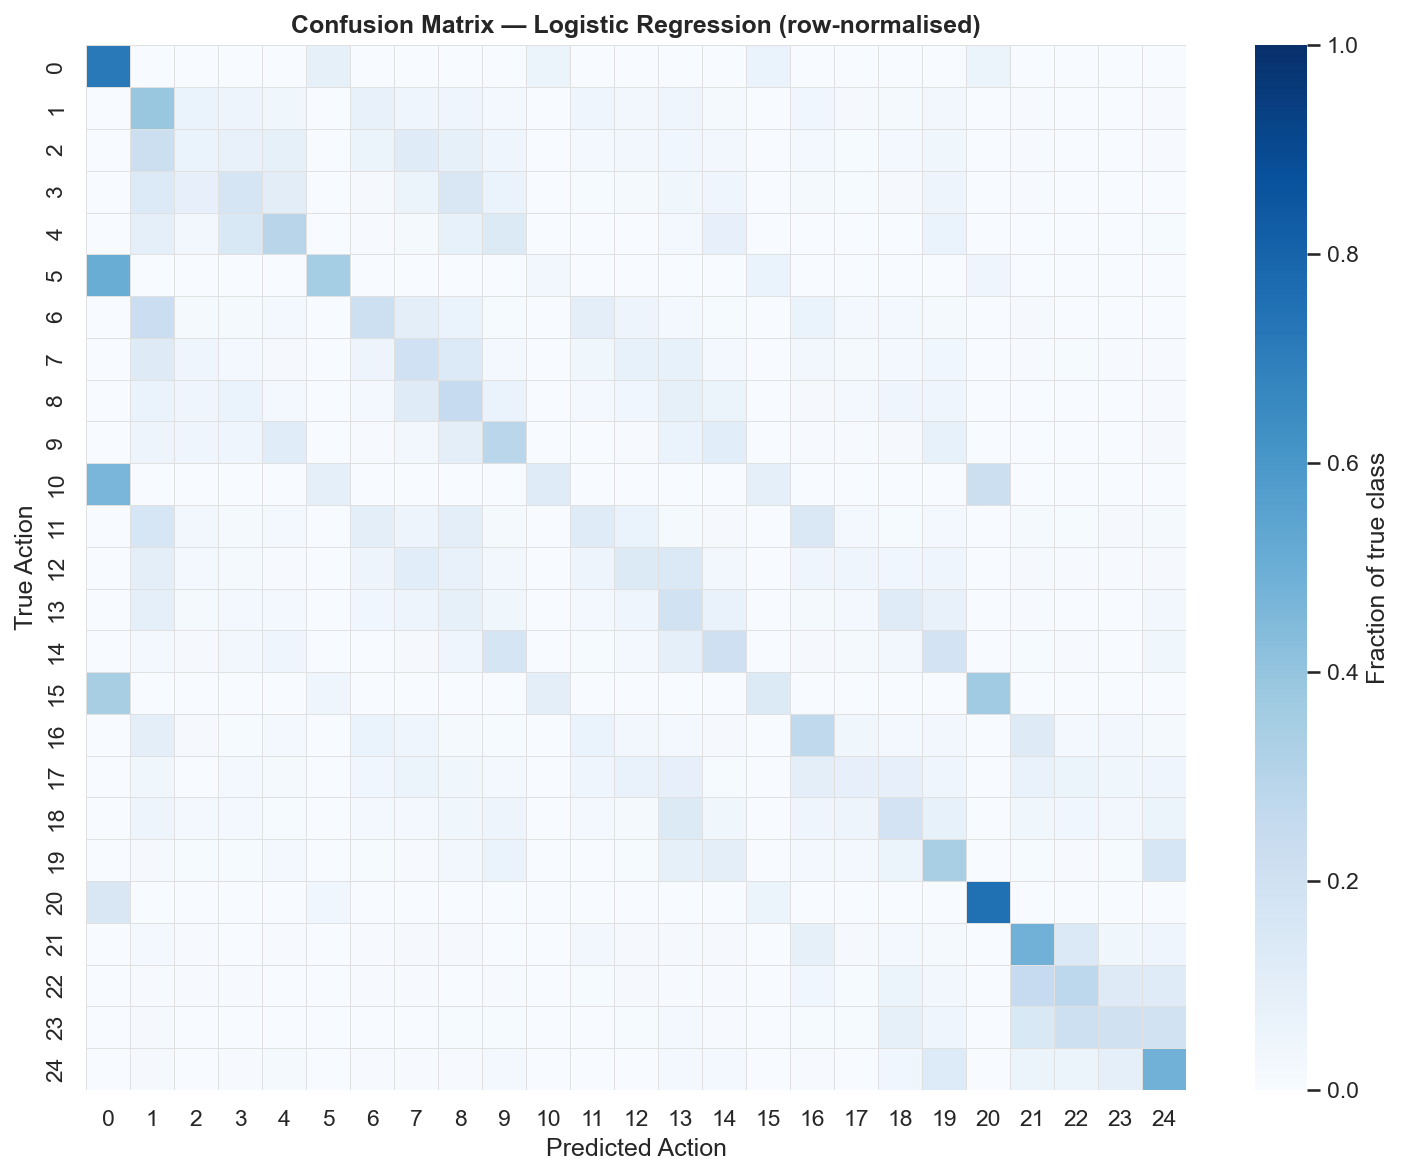

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_lr.png


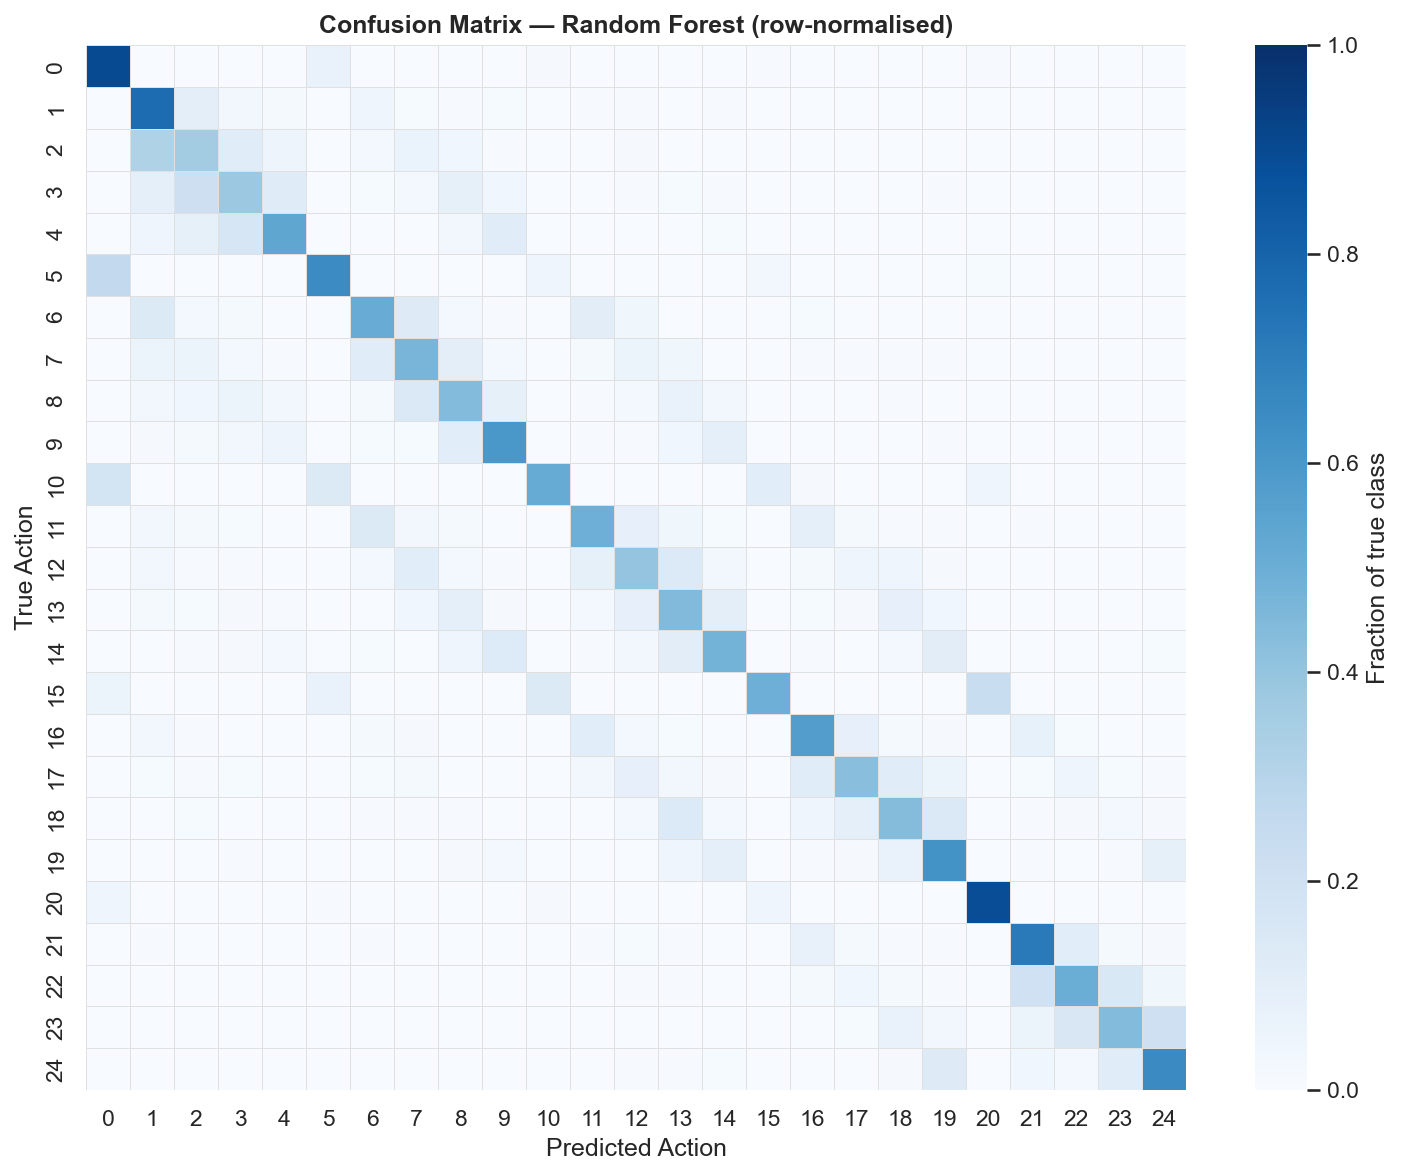

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_rf.png


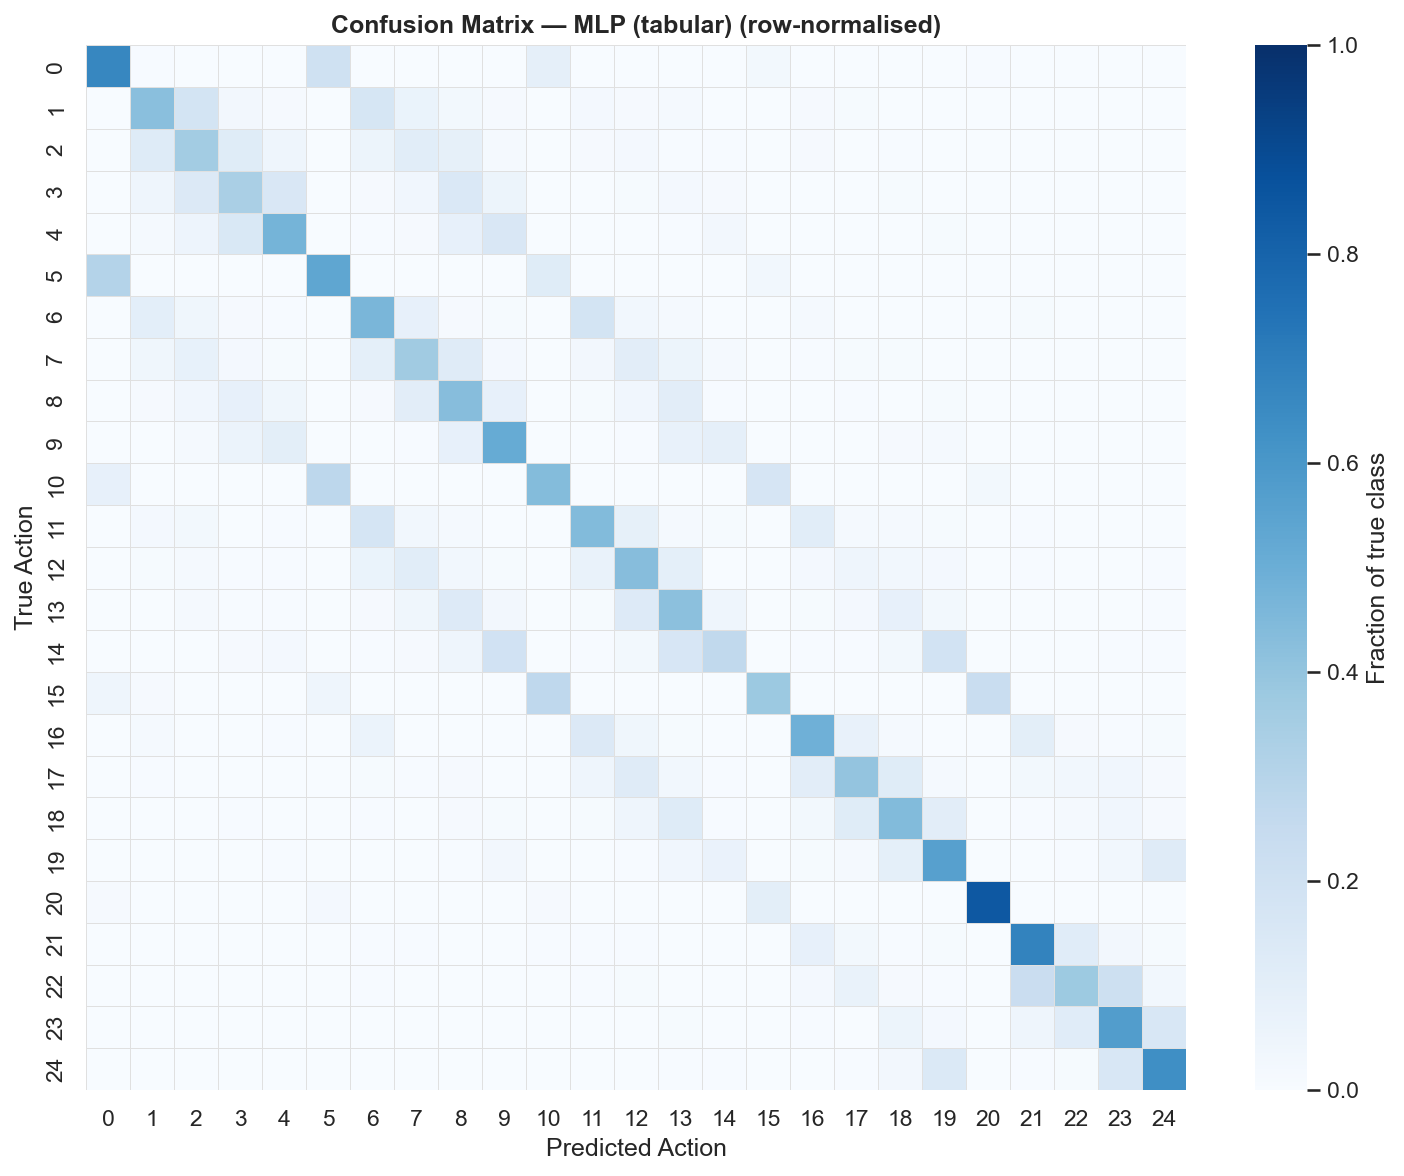

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_mlp.png


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, save_name):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(25), normalize='true')
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, ax=ax, cmap='Blues', vmin=0, vmax=1,
        xticklabels=np.arange(25), yticklabels=np.arange(25),
        linewidths=0.3, linecolor='#e0e0e0',
        cbar_kws={'label': 'Fraction of true class'},
    )
    ax.set_xlabel('Predicted Action')
    ax.set_ylabel('True Action')
    ax.set_title(f'Confusion Matrix — {title} (row-normalised)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_path(save_name), bbox_inches='tight')
    plt.show()
    print(f'Saved → {fig_path(save_name)}')

plot_confusion_matrix(
    y_test, lr_result['model'].predict(X_test_scaled),
    'Logistic Regression', 'confusion_matrix_lr.png'
)
plot_confusion_matrix(
    y_test, rf_result['model'].predict(X_test_scaled),
    'Random Forest', 'confusion_matrix_rf.png'
)
plot_confusion_matrix(
    y_test, mlp_result['model'].predict(X_test_scaled),
    'MLP (tabular)', 'confusion_matrix_mlp.png'
)

### 3.2 Save Tabular Predictions

In [ ]:
df_tab_preds = pd.DataFrame({
    'y_true'    : y_test,
    'y_pred_lr' : lr_result['model'].predict(X_test_scaled),
    'y_pred_rf' : rf_result['model'].predict(X_test_scaled),
    'y_pred_mlp': mlp_result['model'].predict(X_test_scaled),
})
df_tab_preds.to_csv(data_path('tabular_predictions.csv'), index=False)
print(f"Saved → {data_path('tabular_predictions.csv')}")
df_tab_preds.head()

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\data\results\tabular_predictions.csv


,y_true,y_pred_lr,y_pred_rf,y_pred_mlp
0,5,0,5,5
1,19,14,9,19
2,9,13,9,9
3,19,13,13,19
4,11,16,16,11


---
## 4. Imaging Baseline — ResNet-18 (Frozen Backbone)

The imaging baseline works at **patient level**: each patient is represented as
a `T_max × 35` heatmap (base `STATE_COLS` only, no engineered features) resized to
224 × 224 and replicated to 3 channels.  The label is the most-frequent
`action_combined` for that patient.  We load `sepsis_clean.csv` (saved by W2
before feature engineering) so the heatmap uses only raw physiological measurements.

In [ ]:
import torch
import torch.nn as nn
import gc

# We use sepsis_preprocessed.csv (same as tabular baselines).
# prepare_imaging_splits uses STATE_COLS columns only for the heatmap pixels
# and ACTION_COL only for patient-level labels — no feature leakage.
df_img, train_split, val_split, test_split = prepare_imaging_splits(
    df_clean,
    state_cols=STATE_COLS,
    random_state=RANDOM_STATE,
)

train_loader, val_loader, test_loader = build_data_loaders(
    df_img, train_split, val_split, test_split,
    batch_size=32, state_cols=STATE_COLS,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {device}')
print(f'Train patients  : {len(train_split[0])}')
print(f'Val patients    : {len(val_split[0])}')
print(f'Test patients   : {len(test_split[0])}')


Imaging split — Train: 1384 patients, Val: 347, Test: 433
Device          : cpu
Train patients  : 1384
Val patients    : 347
Test patients   : 433


In [ ]:
resnet = build_resnet18(n_actions=25, dropout=0.5)

CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, 'data', 'best_resnet18_sepsis.pth')

resnet, epoch_logs = train_resnet18(
    resnet, train_loader, val_loader,
    n_epochs=20, lr=1e-3,
    save_path=CHECKPOINT_PATH,
    device=device,
    return_logs=True,
)

Epoch  1/20 | Loss: 3.1218 | Val Acc: 0.0865
Epoch  2/20 | Loss: 3.0033 | Val Acc: 0.1153
Epoch  3/20 | Loss: 2.9358 | Val Acc: 0.1297
Epoch  4/20 | Loss: 2.8319 | Val Acc: 0.1556
Epoch  5/20 | Loss: 2.8001 | Val Acc: 0.1729
Epoch  6/20 | Loss: 2.7553 | Val Acc: 0.1729
Epoch  7/20 | Loss: 2.6988 | Val Acc: 0.1873
Epoch  8/20 | Loss: 2.6295 | Val Acc: 0.1988
Epoch  9/20 | Loss: 2.6154 | Val Acc: 0.1931
Epoch 10/20 | Loss: 2.5976 | Val Acc: 0.2161
Epoch 11/20 | Loss: 2.5554 | Val Acc: 0.2017
Epoch 12/20 | Loss: 2.5371 | Val Acc: 0.2075
Epoch 13/20 | Loss: 2.5223 | Val Acc: 0.2133
Epoch 14/20 | Loss: 2.4698 | Val Acc: 0.2046
Epoch 15/20 | Loss: 2.4809 | Val Acc: 0.2046
Epoch 16/20 | Loss: 2.4590 | Val Acc: 0.2133
Epoch 17/20 | Loss: 2.4264 | Val Acc: 0.2075
Epoch 18/20 | Loss: 2.4245 | Val Acc: 0.2104
Epoch 19/20 | Loss: 2.4220 | Val Acc: 0.2104
Epoch 20/20 | Loss: 2.3792 | Val Acc: 0.2075

Best val accuracy: 0.2161 — checkpoint: c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendatio

### 4.1 Training Curve

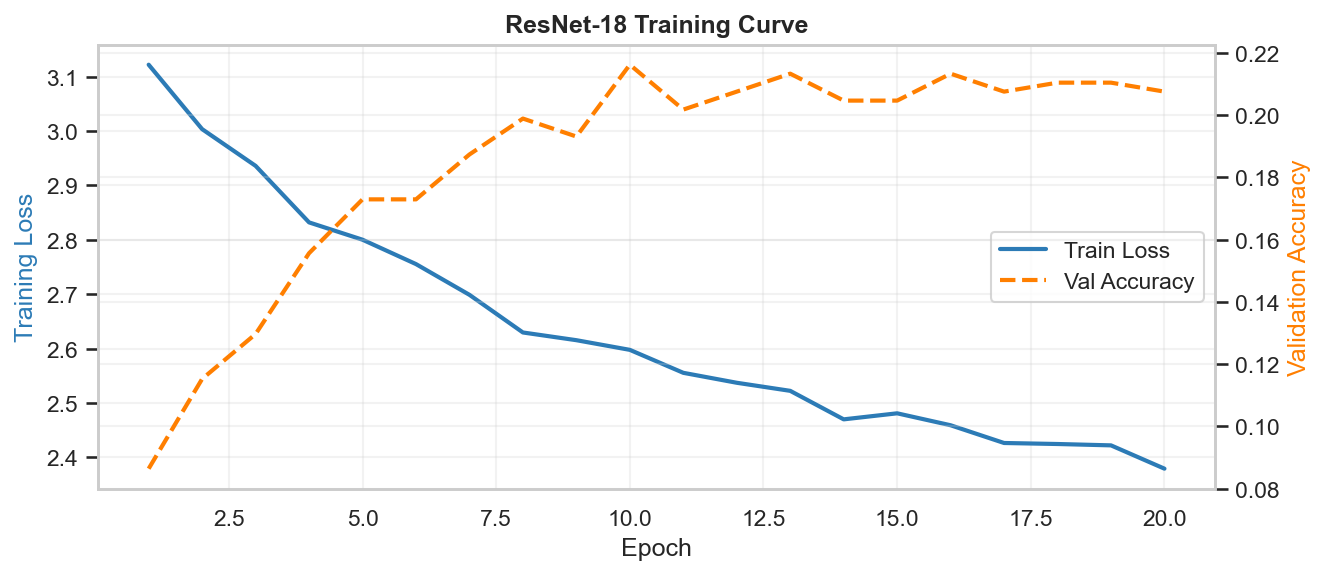

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\resnet18_training_curve.png


In [ ]:
df_logs = pd.DataFrame(epoch_logs)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(df_logs['epoch'], df_logs['loss'],    color=C1,              lw=2, label='Train Loss')
ax2.plot(df_logs['epoch'], df_logs['val_acc'], color=PALETTE['orange'], lw=2, ls='--', label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss',       color=C1)
ax2.set_ylabel('Validation Accuracy', color=PALETTE['orange'])
ax1.set_title('ResNet-18 Training Curve', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.savefig(fig_path('resnet18_training_curve.png'), bbox_inches='tight')
plt.show()
print(f"Saved → {fig_path('resnet18_training_curve.png')}")

### 4.2 Test Evaluation & Confusion Matrix

ResNet-18 (frozen)             | Accuracy: 0.2079 | Macro F1: 0.1102


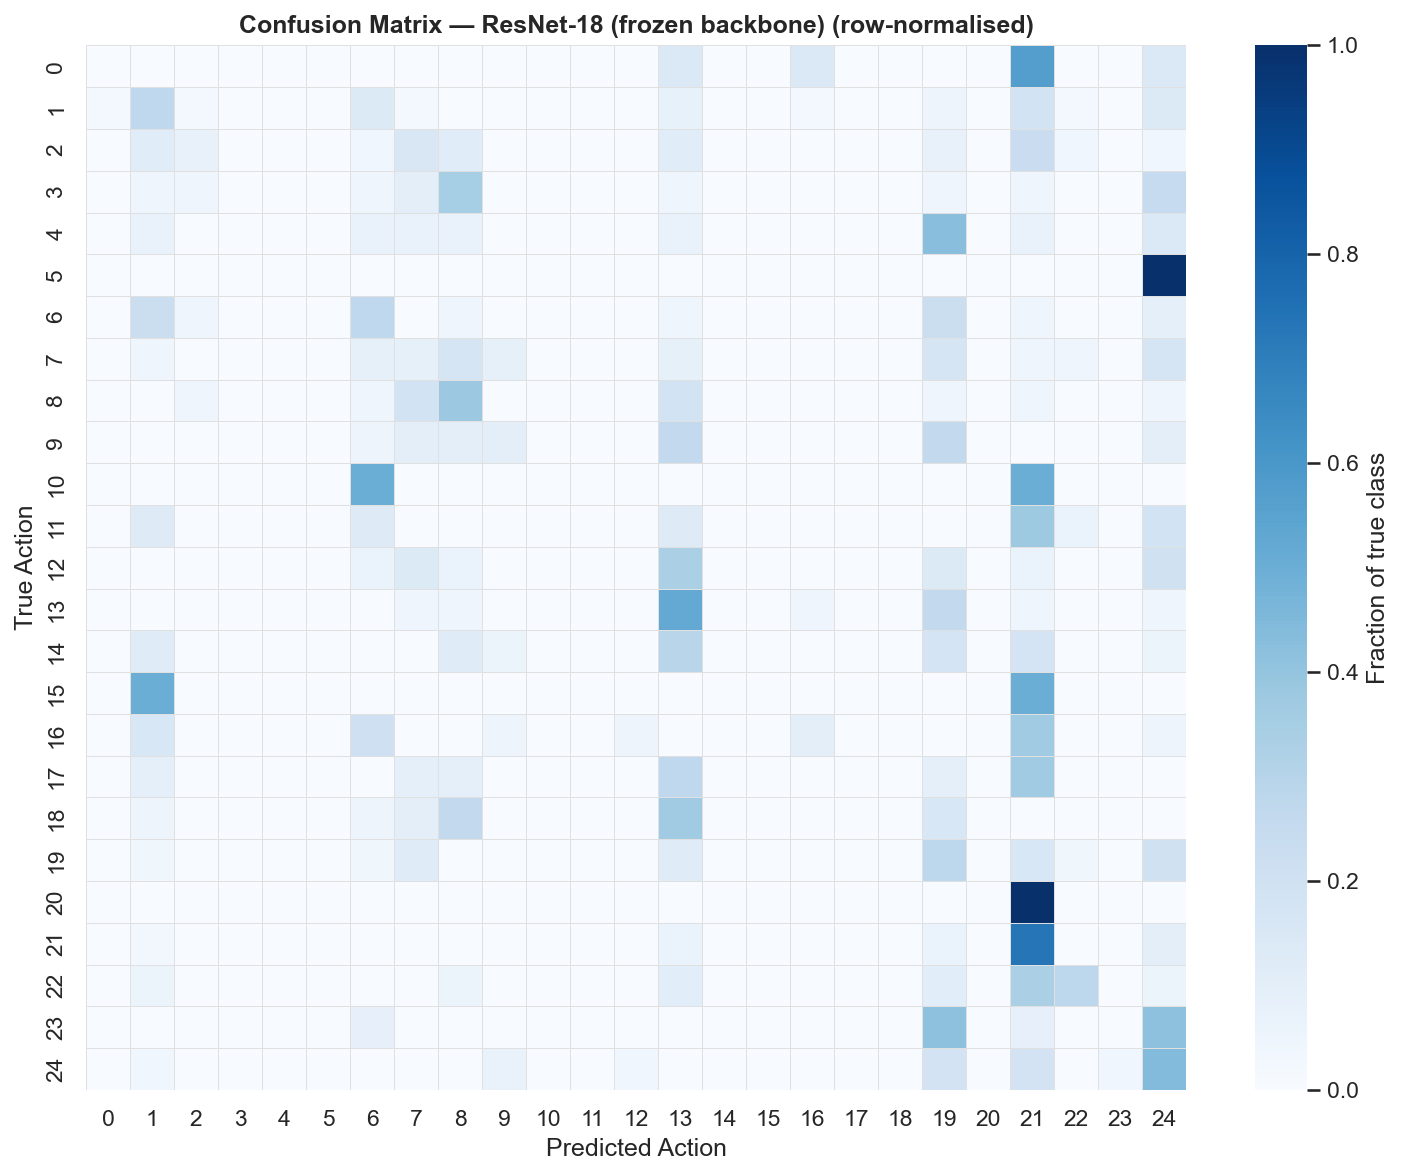

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_resnet18.png


In [ ]:
resnet_result = evaluate_resnet18(resnet, test_loader, device=device)

resnet.eval()
resnet_preds, resnet_true = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, pred = torch.max(resnet(images), 1)
        resnet_preds.extend(pred.cpu().numpy())
        resnet_true.extend(labels.numpy())

plot_confusion_matrix(
    resnet_true, resnet_preds,
    'ResNet-18 (frozen backbone)', 'confusion_matrix_resnet18.png'
)

---
## 5. Behaviour Cloning — MDP Format

Loads the `(states, actions)` arrays from the `.npz` file saved by W2.  
States are the `STATE_EXT` feature vectors at each transition — same feature space
as the tabular baselines, but drawn from the MDP builder output.

In [ ]:
NPZ_PATH = os.path.join(PROJECT_ROOT, 'data', 'preprocessed', 'sepsis_mdp_dataset.npz')

states, actions_mdp = load_mdp_transitions(NPZ_PATH)

(
    X_mdp_train, X_mdp_val, X_mdp_test,
    y_mdp_train, y_mdp_val, y_mdp_test,
    scaler_mdp,
) = split_and_scale_mdp(states, actions_mdp, random_state=RANDOM_STATE)

bc_result = train_and_evaluate_bc(
    X_mdp_train, y_mdp_train,
    X_mdp_test,  y_mdp_test,
    random_state=RANDOM_STATE,
)

Loaded MDP transitions: states=(43279, 56), actions=(43279,)
MDP split — Train: (27698, 56), Val: (6925, 56), Test: (8656, 56)
Behaviour Cloning (MDP)        | Accuracy: 0.4689 | Macro F1: 0.4796


### 5.1 Confusion Matrix & Predictions

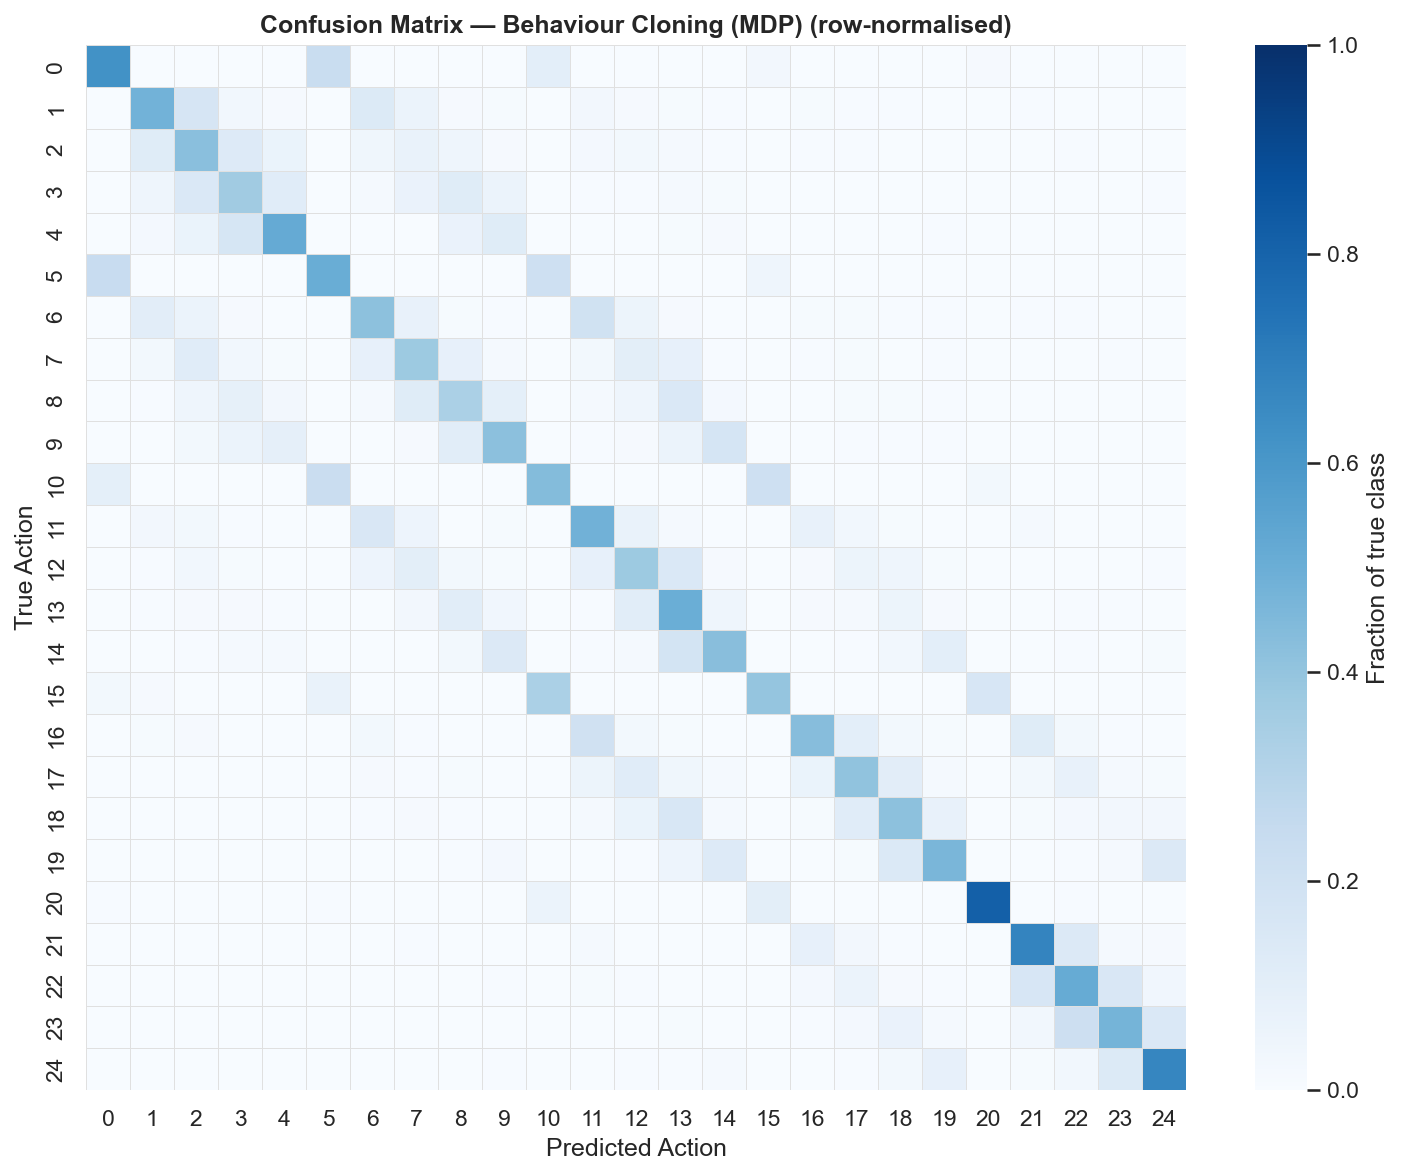

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_bc_mdp.png
Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\data\results\bc_mdp_predictions.csv


In [ ]:
bc_preds = bc_result['model'].predict(X_mdp_test)

plot_confusion_matrix(
    y_mdp_test, bc_preds,
    'Behaviour Cloning (MDP)', 'confusion_matrix_bc_mdp.png'
)

df_bc_preds = pd.DataFrame({'y_true': y_mdp_test, 'y_pred_bc': bc_preds})
df_bc_preds.to_csv(data_path('bc_mdp_predictions.csv'), index=False)
print(f"Saved → {data_path('bc_mdp_predictions.csv')}")

---
## 6. Results Summary

In [ ]:
all_results = [lr_result, rf_result, mlp_result, resnet_result, bc_result]

df_results = build_results_table(all_results)
print_results_table(df_results)

save_results_csv(df_results, data_path('baseline_results.csv'))
df_results


Baseline Results Summary
                  Model  Accuracy  Macro F1
    Logistic Regression    0.2631    0.2705
          Random Forest    0.5314    0.5498
          MLP (tabular)    0.4655    0.4768
     ResNet-18 (frozen)    0.2079    0.1102
Behaviour Cloning (MDP)    0.4689    0.4796

Results saved to c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\data\results\baseline_results.csv


,Model,Accuracy,Macro F1
0,Logistic Regression,0.2631,0.2705
1,Random Forest,0.5314,0.5498
2,MLP (tabular),0.4655,0.4768
3,ResNet-18 (frozen),0.2079,0.1102
4,Behaviour Cloning (MDP),0.4689,0.4796
